# Задание 8 (Контрольные вопросы)
## Тема: Корреляционно-регрессионный анализ

### Настройка окружения

In [448]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn import metrics

### 1. Что такое корреляция? Свойства коэффициента корреляции.

***Корреляция*** — это мера линейной взаимосвязи между двумя величинами.

*Свойства корреляции:*

- изменяется от -1 до 1;
- положительный коэффициент корреляции свидетельствует о прямой зависимости;
- отрицательный коэффициент корреляции свидетельствует об обратной зависимости;
- не зависит от масштаба: изменение масштаба переменных не влияет на значение 
$𝑟$.

### 2. Формула вычисления коэффициента корреляции. Реализуйте формулу на *Python* и проверьте результаты вычислений по данным примера на стр. 4.

Коэффициент корреляции вычисляется по *формуле Пирсона*:

$$
r = \frac{\sum (x - \bar{x}) \cdot (y - \bar{y})}
         {\sqrt{\sum (x - \bar{x})^2 \cdot \sum (y - \bar{y})^2}}

$$

In [449]:
def pearson_correlation(x: np.typing.ArrayLike, y: np.typing.ArrayLike) -> float:
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    numerator = np.sum((x - mean_x) * (y - mean_y))
    denominator = np.sqrt(np.sum((x - mean_x) ** 2) * np.sum((y - mean_y) ** 2))
    return numerator / denominator


X = [2, 4, 1, 3, 5]
Y = [6, 8, 1, 7, 3]

r = pearson_correlation(X, Y)

print(f"Коэффициент корреляции: {r:.2f}")

Коэффициент корреляции: 0.33


### 3. Интерпретация корреляции.

Корреляция свидетельствует о взаимосвязи между величинами (но не о причинно-следственной связи). Если мы знаем о связи, мы можем:

- прогнозировать значение одной переменной по другим;
- использовать корреляцию для оценки валидности тестов;
- вычислять надежность оценочных инструментов.

### 4. Визуальный анализ наличия зависимостей в данных: диаграммы *scatterplot, regplot, swarmplot, pairplot.* Назначение каждого вида диаграмм и пример использования на своих данных.

*Данные для примера использования:*

In [450]:
data = pd.DataFrame(
    {
        "StudyHours": [5, 8, 3, 10, 6, 7, 4, 9, 6, 8],
        "ExtraClasses": [
            "Yes",
            "Yes",
            "No",
            "Yes",
            "No",
            "Yes",
            "No",
            "Yes",
            "No",
            "Yes",
        ],
        "ExamScore": [70, 85, 60, 90, 75, 80, 65, 88, 78, 82],
        "Age": [20, 21, 19, 22, 20, 21, 19, 22, 20, 21],
        "StudyGroup": ["A", "B", "A", "C", "B", "A", "C", "B", "A", "C"],
    }
)

Для визуального анализа зависимостей между переменными используются различные виды диаграмм:

- **Scatterplot (Точечная диаграмма).** Показывает взаимосвязь между двумя числовыми переменными. Каждая точка представляет пару значений ($X$, $Y$). Позволяет оценить направление (положительное/отрицательное), силу (тесная/слабая) и форму (линейная/нелинейная) зависимости.

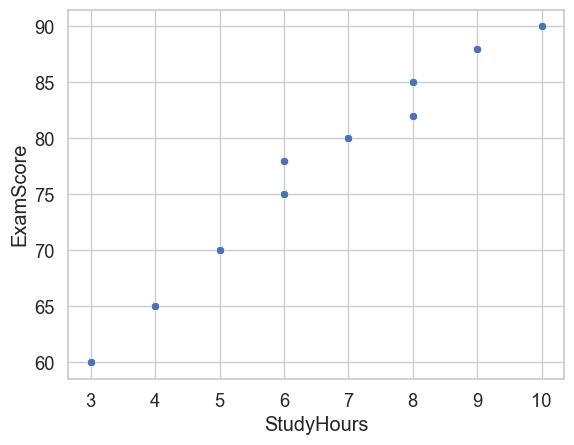

In [451]:
sns.scatterplot(data, x="StudyHours", y="ExamScore");

- *Regplot.* Позволяет увидеть линию регрессии и доверительный интервал для предсказания тренда.

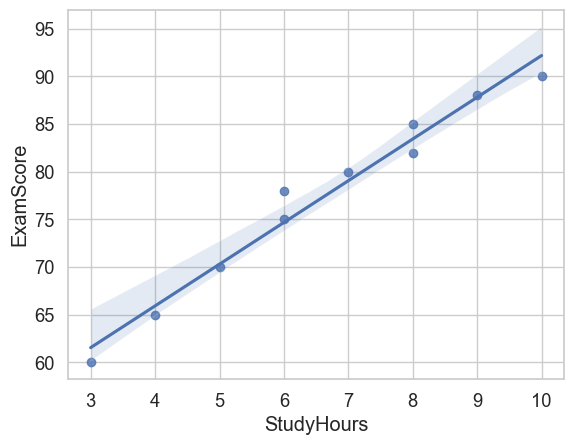

In [452]:
sns.regplot(data, x='StudyHours', y='ExamScore');

- *Swarmplot.* Используется для визуализации категориальных характеристик. Она автоматически отображает точки без наложения, позволяя оценить, где находится основная часть значений.

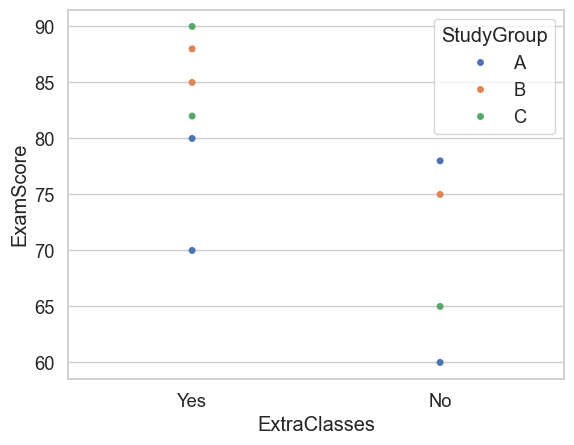

In [453]:
sns.swarmplot(data, x="ExtraClasses", y="ExamScore", hue="StudyGroup");

- *Pairplot.* Это визуализация зависимостей в данных, которая представляет собой таблицу из нескольких графиков.

    На недиагональных элементах *Pairplot* расположены диаграммы
    разброса. По диагонали показаны графики распределения значений. На осях
    отмечены названия характеристик, для которые отражены на графиках,
    и их значения.

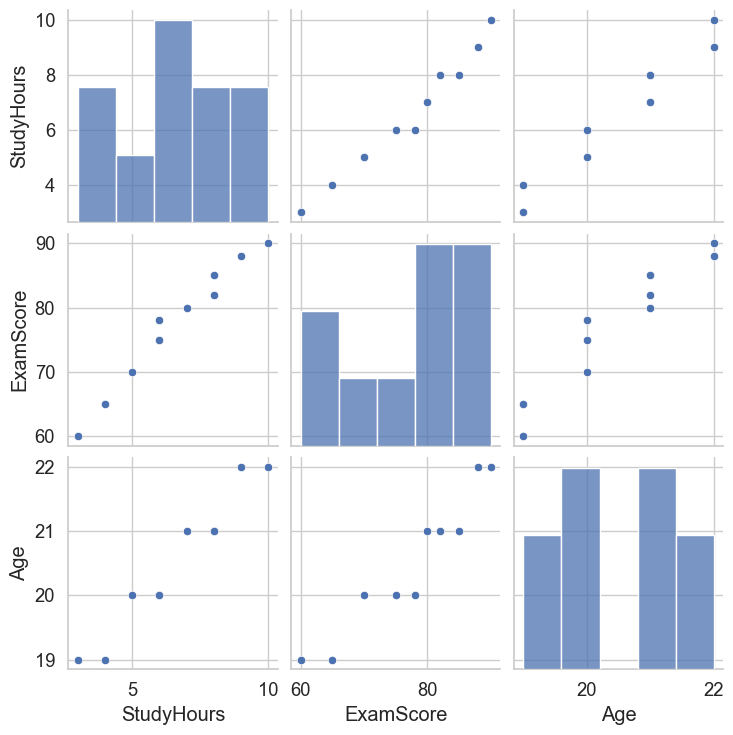

In [454]:
sns.pairplot(data);

### 5. Вычисление корреляции в *Pandas*.

In [455]:
correlation = data['StudyHours'].corr(data['ExamScore'])
print(f"Коэффициент корреляции: {correlation:.2f}")

Коэффициент корреляции: 0.99


### 6. Построение коррелограммы.

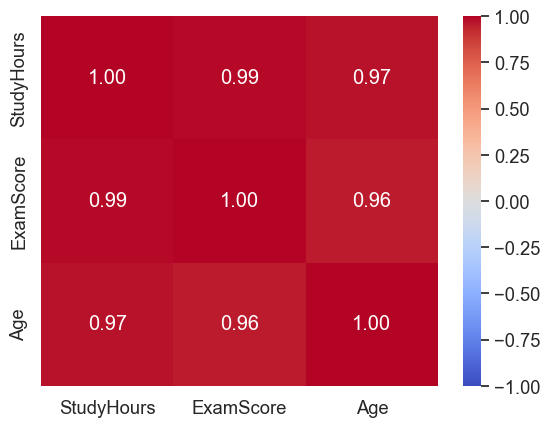

In [456]:
sns.heatmap(
    data.drop(["ExtraClasses", "StudyGroup"], axis=1).corr(),
    annot=True,
    fmt=".2f",
    vmax=1,
    vmin=-1,
    cmap="coolwarm",
);

### 7. Понятие линейной регрессии, интерпретация коэффициентов.

***Линейная регрессия*** — это статистический метод, который моделирует линейную зависимость между:

- целевой переменной ($Y$) — зависимая переменная, которую мы хотим предсказать.
- признаками ($X_1, X_2, ..., X_n$) — независимые переменные, влияющие на $Y$.

*Уравнение линейной регрессии:*

$$
y = b_0 + b_1 x_1 + b_2 x_2 + \dots + b_n x_n
$$

*Коэффициенты линейной регрессии* показывают, как изменение признака влияет на целевую переменную при условии, что остальные признаки фиксированы.

### 8. Алгоритм нахождения коэффициентов линейной регрессии по методу наименьших квадратов.

Для простого уравнения линейной регрессии с одной независимой переменной можно использовать следующие формулы для нахождения коэффициентов:

$$
a = \frac{\sum_{i=1}^{n}(x_i - \bar{x}) \cdot (y_i - \bar{y})}{\sum_{i=1}^{n}(x_i - \bar{x})^2}
$$

$$
b = \bar{y} - a \cdot \bar{x}
$$

В общем случае с *n* независимыми переменными необходимо найти вектор *β*, минимизирующий сумму квадратов ошибок.

$$
SSE = \sum_{i=1}^{n} (Y_i - \hat{Y}_i)^2 = \lVert Y - X \beta \rVert^2
$$

Аналитически минимум достигается, когда производная этого уравнения равна нулю. Т.е. необходимо решить:

$$
\beta = (X^T X)^{-1} X^T Y
$$


### 9. Программная реализация нахождения коэффициентов для модели линейной регрессии вида: $y = a \cdot x + b$. Выполните проверку на данных примера зависимости стоимости квартиры от площади стр. 20.

In [457]:
X = [35, 51, 43, 38, 68, 66, 49, 50]
Y = [3, 6, 3, 5, 8, 5, 6, 4]


n = len(X)
MX = sum(X) / n
MY = sum(Y) / n

numerator = sum((x - MX) * (y - MY) for x, y in zip(X, Y))
denominator = sum((x - MX) ** 2 for x in X)
a = numerator / denominator
b = MY - a * MX
print(f"Уравнение регрессии: y = {a:.3f}*x + {b:.3f}")

Уравнение регрессии: y = 0.098*x + 0.100


In [458]:
y_pred = [(a * x + b) for x in X]
pd.DataFrame(
    {
        "x": X,
        "y": Y,
        "y_pred": y_pred,
    }
)

,x,y,y_pred
0,35,3,3.530
1,51,6,5.098
2,43,3,4.314
3,38,5,3.824
4,68,8,6.764
5,66,5,6.568
6,49,6,4.902
7,50,4,5.000


### 10. Метрики оценки качества линейной регрессии.

- **MSE (среднеквадратичная ошибка).** Вычисляется как сумма квадратов ошибок, разделенная на количество наблюдений. *MSE* не зависит от каких-либо единиц измерения. Только сравнивая различные уравнения регрессии по MSE можно выбрать лучший - тот, у которого *MSE* минимальна.

$$
\text{MSE} = \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{n}
$$

- **MAE (средняя абсолютная ошибка).** Вычисляется как сумма абсолютных значений ошибок, разделенная на количество наблюдений.

$$
\text{MAE} = \frac{\sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|}{n}
$$

- **$R^2$ (коэффициент детерминации).** Коэффициент детерминации отражает, какой процент разброса данных мы можем объяснить нашей моделью.

$$
R^2 = \frac{\sum_{i=1}^{n} (\hat{y}_i - \bar{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}
$$

### 11. Множественная линейная регрессия: вид уравнения и описание модели.

Зачастую значение определенного признака зависит линейно от множества переменных. В этом случае необходимо построить множественную линейную регрессию.

*Уравнение множественной линейной регрессии:*

$$
y = b_0 + b_1 x_1 + b_2 x_2 + \dots + b_n x_n
$$

### 12. Предпосылки линейной регрессии.

Модель линейной регрессии можно построить не для любых данных, а только для данных, которые удовлетворяют ряду условий:

- **линейная зависимость;**

- **гомоскедастичность** (разброс остатков при любых значениях независимых переменных одинаковый);

- **отсутствие мультиколлинеарности** (линейной зависимости между независимыми переменными);

- **нормальное распределение ошибок;**

- **отсутствие автокорреляции остатков.** Автокорреляция остатков (ошибок) возникает в ситуации, когда есть линейная взаимосвязь между остатками для одних значений предикторов и остатками для других значений предикторов.

### 13. Способы построения модели линейной регрессии в *Python*.

*Данные для примера способов:*

In [459]:
data = pd.DataFrame(
    {
        "Hours": [1, 2, 3, 4, 5, 6, 7, 8, 9],
        "Score": [42, 45, 50, 55, 60, 65, 70, 75, 78],
    }
)

- с использованием пакета ***statsmodels***.

In [460]:
import statsmodels.api as sm

X = data["Hours"]
y = data["Score"]

X = sm.add_constant(X)

model = sm.OLS(y, X)
res = model.fit()

round(res.params, 2)

const    36.33
Hours     4.73
dtype: float64

- с использованием пакета ***sklearn***

In [461]:
X = data[["Hours"]]
y = data["Score"]

model = LinearRegression()
model.fit(X, y)

print(f"Свободный коэффициент (intercept): {model.intercept_:.2f}")
print(f"Коэффициент наклона (slope): {model.coef_[0]:.2f}")

Свободный коэффициент (intercept): 36.33
Коэффициент наклона (slope): 4.73


### 14. Задание
Постройте модель линейной регрессии для следующей задачи: предположим, мы хотим знать, влияет ли количество часов, потраченных на подготовку, и количество посещенных факультативов на оценку, которую студент получает на определенном экзамене. Выведите получившиеся коэффициенты линейной модели, оцените качество модели с использованием различных метрик. Попробуйте предсказать оценку за экзамен для студента, который потратил 8 часов на подготовку и посещал в течении семестра 2 факультатива. Перед построением модели проведите предварительный визуальный анализ данных с использованием диаграмм п.4. Данные для анализа находятся в файле [exams.csv](./exams.csv).

*Загрузка данных:*

In [462]:
exams = pd.read_csv("exams.csv", index_col=0)
exams.head(1)

,hours,optional_course,score
0,1,1,76


*Визуальный анализ данных:*

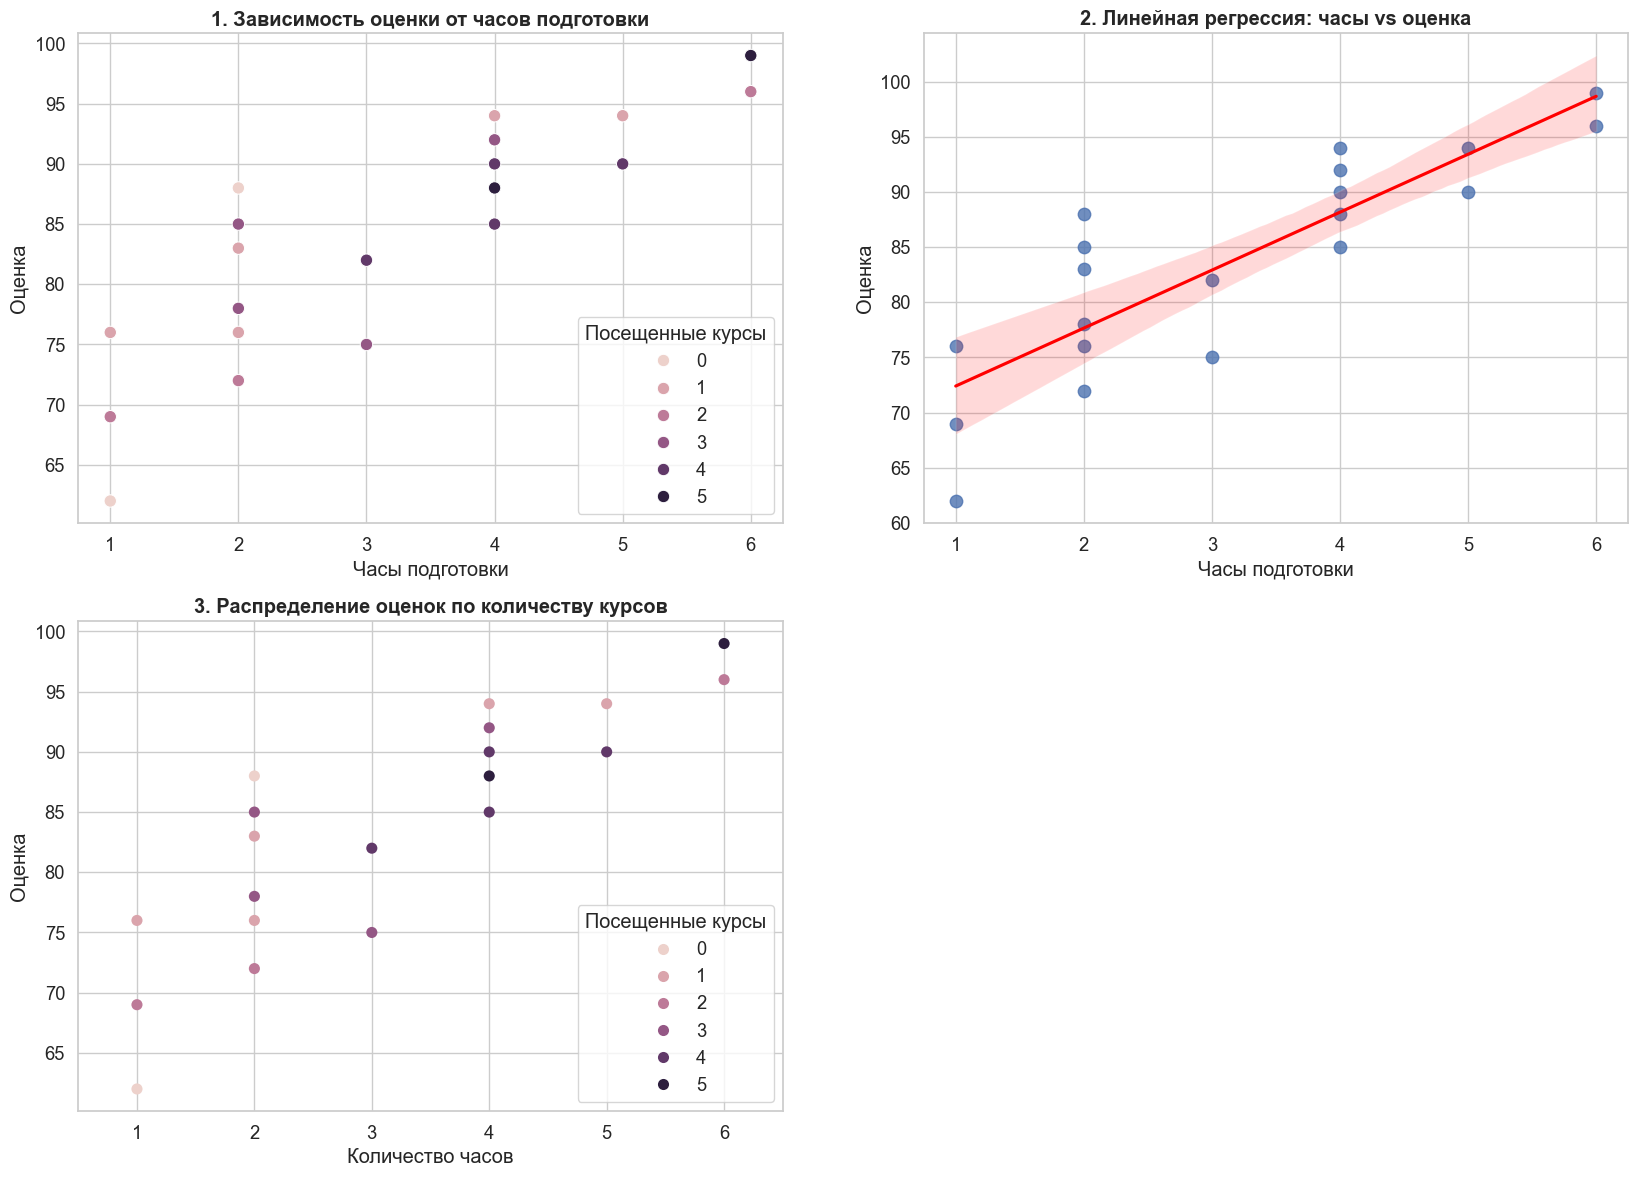

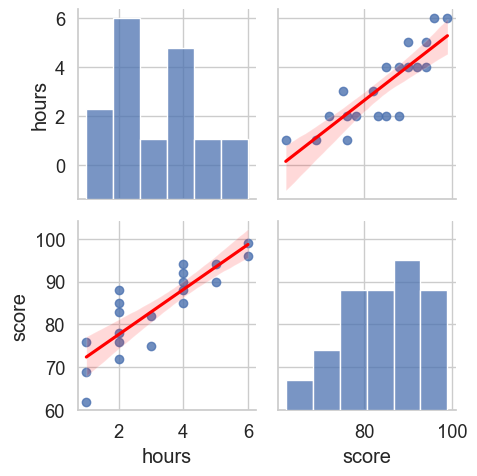

In [463]:
def set_labels(title: str, xlabel: str, ylabel: str) -> None:
    plt.title(title, fontweight="bold")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)


plt.figure(figsize=(20, 14))

plt.subplot(2, 2, 1)
sns.scatterplot(data=exams, x="hours", y="score", hue="optional_course", s=80)
set_labels("1. Зависимость оценки от часов подготовки", "Часы подготовки", "Оценка")
plt.legend(title="Посещенные курсы")

plt.subplot(2, 2, 2)
sns.regplot(
    data=exams, x="hours", y="score", scatter_kws={"s": 80}, line_kws={"color": "red"}
)
set_labels("2. Линейная регрессия: часы vs оценка", "Часы подготовки", "Оценка")

plt.subplot(2, 2, 3)
sns.swarmplot(data=exams, x="hours", y="score", size=8, hue="optional_course")
set_labels("3. Распределение оценок по количеству курсов", "Количество часов", "Оценка")
plt.legend(title="Посещенные курсы")

sns.pairplot(
    exams[["hours", "score"]],
    kind="reg",
    plot_kws={"line_kws": {"color": "red"}},
)

plt.tight_layout()

*Построение модели линейной регрессии:*

In [464]:
X = exams[["hours", "optional_course"]]
y = exams["score"]

exams_regressor = LinearRegression()
exams_regressor.fit(X, y)

intercept = exams_regressor.intercept_
coef_hours = exams_regressor.coef_[0]
coef_optional = exams_regressor.coef_[1]

print(f"Уравнение линейной регрессии:")
print(
    f"score = {intercept:.2f} + {coef_hours:.2f} * hours + {coef_optional:.2f} * optional_course\n"
)

print(f"Свободный коэффициент (intercept): {intercept:.2f}")
print(f"Коэффициент при 'hours' (часы подготовки): {coef_hours:.2f}")
print(f"Коэффициент при 'optional_course' (кол-во факультативов): {coef_optional:.2f}")

Уравнение линейной регрессии:
score = 67.67 + 5.56 * hours + -0.60 * optional_course

Свободный коэффициент (intercept): 67.67
Коэффициент при 'hours' (часы подготовки): 5.56
Коэффициент при 'optional_course' (кол-во факультативов): -0.60


*Оценка качества модели:*

In [465]:
predicted_y = exams_regressor.predict(X)

mse = metrics.mean_squared_error(y, predicted_y)
mae = metrics.mean_absolute_error(y, predicted_y)
rmse = metrics.root_mean_squared_error(y, predicted_y)
mape = metrics.mean_absolute_percentage_error(y, predicted_y)
r2 = metrics.r2_score(y, predicted_y)

print(f"1. MSE (среднеквадратичная ошибка): {mse:.2f}")
print(f"2. RMSE (корень из MSE): {rmse:.2f}")
print(f"3. MAE (средняя абсолютная ошибка): {mae:.2f}")
print(f"4. MAPE (средняя абсолютная процентная ошибка): {mape:.2%}")
print(f"5. R² (коэффициент детерминации): {r2:.3f}")

1. MSE (среднеквадратичная ошибка): 24.47
2. RMSE (корень из MSE): 4.95
3. MAE (средняя абсолютная ошибка): 3.97
4. MAPE (средняя абсолютная процентная ошибка): 5.01%
5. R² (коэффициент детерминации): 0.734


*Прогноз: какая будет оценка у студента, который потратил 8 часов на подготовку и посещал в течении семестра 2 факультатива.*

In [466]:
student = pd.DataFrame({"hours": [8], "optional_course": [2]})

predicted_score = exams_regressor.predict(student)[0]

print(f"Прогнозируемая оценка: {predicted_score:.0f}")

Прогнозируемая оценка: 111


#### Экспорт в html

In [467]:
from os import system

system("jupyter nbconvert --to html task_8.ipynb")

[NbConvertApp] Converting notebook task_8.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 725802 bytes to task_8.html


0